In [1]:
import torch
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from collections import OrderedDict
import re

torch.manual_seed(0)
np.random.seed(0)

class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2
        self.scale = (1 / (in_channels * out_channels))
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        x_ft = torch.fft.rfft2(x)
        
        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-2), x.size(-1)//2 + 1, 
                           dtype=torch.cfloat, device=x.device)
        
        out_ft[:, :, :self.modes1, :self.modes2] = \
            self.compl_mul2d(x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = \
            self.compl_mul2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)
            
        return torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))

class MLP(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, 1),
            nn.GELU(),
            nn.Conv2d(mid_channels, out_channels, 1)
        )

    def forward(self, x):
        return self.mlp(x)

class FNO2d(nn.Module):
    def __init__(self, modes1, modes2, width, num_layers=4, in_channels=10):
        super().__init__()
        self.modes1 = modes1
        self.modes2 = modes2
        self.width = width
        self.num_layers = num_layers
        # self.padding = 9

        self.p = nn.Linear(in_channels+2, self.width)
        
        # Initialize layers dynamically
        self.conv_layers = nn.ModuleList()
        self.mlp_layers = nn.ModuleList()
        self.w_layers = nn.ModuleList()
        
        for _ in range(num_layers):
            self.conv_layers.append(SpectralConv2d(self.width, self.width, modes1, modes2))
            self.mlp_layers.append(MLP(self.width, self.width, self.width))
            self.w_layers.append(nn.Conv2d(self.width, self.width, 1))
        
        self.q = MLP(self.width, 1, self.width * 4)

    def forward(self, x):
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)
        x = self.p(x)
        x = x.permute(0, 3, 1, 2)
        # x = F.pad(x, [0, self.padding, 0, self.padding])

        for i in range(self.num_layers):
            x1 = self.conv_layers[i](x)
            x1 = self.mlp_layers[i](x1)
            x2 = self.w_layers[i](x)
            x = x1 + x2
            if i < self.num_layers - 1:  # No GELU after last layer
                x = F.gelu(x)

        # x = x[..., :-self.padding, :-self.padding]
        x = self.q(x)
        return x.permute(0, 2, 3, 1)

    def get_grid(self, shape, device):
        batchsize, size_x, size_y = shape[0], shape[1], shape[2]
        gridx = torch.linspace(0, 1, size_x, dtype=torch.float, device=device)
        gridy = torch.linspace(0, 1, size_y, dtype=torch.float, device=device)
        gridx = gridx.reshape(1, size_x, 1, 1).repeat([batchsize, 1, size_y, 1])
        gridy = gridy.reshape(1, 1, size_y, 1).repeat([batchsize, size_x, 1, 1])
        return torch.cat((gridx, gridy), dim=-1)


class RecurrentPredictor(torch.nn.Module):
    def __init__(self, model, T_out=10, step=1):
        super().__init__()
        self.model = model
        self.T_out = T_out
        self.step = step

    def forward(self, x_init):
        # x_init: (batch, s, s, T_in=10)
        batch_size, s1, s2, T_in = x_init.shape
        outputs = []

        x = x_init
        for _ in range(0, self.T_out, self.step):
            y_pred = self.model(x)  # 预测后面1帧，形状(batch, s, s, step)
            outputs.append(y_pred)
            # 滚动输入：删掉最前面step帧，拼接新预测帧
            x = torch.cat([x[..., self.step:], y_pred], dim=-1)

        # 拼接所有预测帧，变成(batch, s, s, T_out)
        return torch.cat(outputs, dim=-1)  


ckpt_path = "modes96_width80_epochs500_Tin10_T10/NS_2d_FNO_model_trainedby_dim2d_nx256_N1150_solver=exponax_nu0.000_t20.0_train_all_frames.pth"

ckpt = torch.load(ckpt_path, map_location="cpu")  # weights-only file -> OrderedDict OR dict

# 1) extract the actual state_dict
if isinstance(ckpt, OrderedDict):
    state_dict = ckpt
elif isinstance(ckpt, dict):
    # common wrappers
    for k in ["state_dict", "model_state_dict", "model", "net", "module"]:
        if k in ckpt and isinstance(ckpt[k], (dict, OrderedDict)):
            state_dict = ckpt[k]
            break
    else:
        raise ValueError(f"Unexpected checkpoint keys: {list(ckpt.keys())[:10]}")
else:
    raise TypeError(f"Unexpected checkpoint type: {type(ckpt)}")

# 2) strip common prefixes (DDP/DataParallel or a top-level 'model.')
def strip_prefix(sd, prefixes=("module.", "model.", "model.module.")):
    new_sd = OrderedDict()
    for k, v in sd.items():
        for p in prefixes:
            if k.startswith(p):
                k = k[len(p):]
                break
        new_sd[k] = v
    return new_sd

state_dict = strip_prefix(state_dict)

# 3) infer architecture hyper-params from the weight shapes
# width from a 1x1 conv
width = state_dict[[k for k in state_dict if k.startswith("w_layers.0.weight")][0]].shape[0]
# modes from spectral conv weights
modes1, modes2 = state_dict[[k for k in state_dict if k.endswith("conv_layers.0.weights1")][0]].shape[-2:]
# Tin (in_channels) from the input linear 'p': p: Linear(in_channels+2, width)
Tin_plus_2 = state_dict["p.weight"].shape[1]
Tin = Tin_plus_2 - 2
# number of layers from highest conv_layers index
layer_idxs = [int(re.findall(r"conv_layers\.(\d+)\.", k)[0]) for k in state_dict if k.startswith("conv_layers.")]
num_layers = max(layer_idxs) + 1

print(f"Inferred: modes1={modes1}, modes2={modes2}, width={width}, num_layers={num_layers}, Tin={Tin}")

# 4) instantiate model and (optionally) the recurrent wrapper
core = FNO2d(modes1=modes1, modes2=modes2, width=width, num_layers=num_layers, in_channels=Tin)

# If your checkpoint was saved from RecurrentPredictor(model=FNO2d(...)),
# the keys will start with "model." (we already stripped), but parameters still match the inner model.
# Try loading directly into the core; if many keys are missing, try wrapping:
missing, unexpected = core.load_state_dict(state_dict, strict=False)
if len(missing) > 0 and all(k.startswith("model.") for k in strip_prefix(ckpt if isinstance(ckpt, OrderedDict) else ckpt.get("state_dict", {})).keys()):
    wrapper = RecurrentPredictor(core)
    missing, unexpected = wrapper.load_state_dict(state_dict, strict=False)
    model = wrapper
else:
    model = core

print("Missing keys:", missing)
print("Unexpected keys:", unexpected)
model.eval()

Inferred: modes1=96, modes2=96, width=80, num_layers=4, Tin=10
Missing keys: []
Unexpected keys: []


FNO2d(
  (p): Linear(in_features=12, out_features=80, bias=True)
  (conv_layers): ModuleList(
    (0-3): 4 x SpectralConv2d()
  )
  (mlp_layers): ModuleList(
    (0-3): 4 x MLP(
      (mlp): Sequential(
        (0): Conv2d(80, 80, kernel_size=(1, 1), stride=(1, 1))
        (1): GELU(approximate='none')
        (2): Conv2d(80, 80, kernel_size=(1, 1), stride=(1, 1))
      )
    )
  )
  (w_layers): ModuleList(
    (0-3): 4 x Conv2d(80, 80, kernel_size=(1, 1), stride=(1, 1))
  )
  (q): MLP(
    (mlp): Sequential(
      (0): Conv2d(80, 320, kernel_size=(1, 1), stride=(1, 1))
      (1): GELU(approximate='none')
      (2): Conv2d(320, 1, kernel_size=(1, 1), stride=(1, 1))
    )
  )
)

In [6]:
def get_fno_core(m):
    # unwrap RecurrentPredictor if needed
    return m.model if hasattr(m, "model") and hasattr(m.model, "conv_layers") else m

core = get_fno_core(model)  # <-- your loaded/constructed model instance

print("Found", len(core.conv_layers), "SpectralConv2d layers")
for i, sc in enumerate(core.conv_layers):
    w1, w2 = sc.weights1, sc.weights2  # nn.Parameter (Tensor) with dtype torch.cfloat
    print(
        f"[layer {i}] "
        f"in={sc.in_channels}, out={sc.out_channels}, "
        f"modes=({sc.modes1},{sc.modes2}); "
        f"weights1.shape={tuple(w1.shape)}, weights2.shape={tuple(w2.shape)}, "
        f"dtype={w1.dtype}"
    )

Found 4 SpectralConv2d layers
[layer 0] in=80, out=80, modes=(96,96); weights1.shape=(80, 80, 96, 96), weights2.shape=(80, 80, 96, 96), dtype=torch.complex64
[layer 1] in=80, out=80, modes=(96,96); weights1.shape=(80, 80, 96, 96), weights2.shape=(80, 80, 96, 96), dtype=torch.complex64
[layer 2] in=80, out=80, modes=(96,96); weights1.shape=(80, 80, 96, 96), weights2.shape=(80, 80, 96, 96), dtype=torch.complex64
[layer 3] in=80, out=80, modes=(96,96); weights1.shape=(80, 80, 96, 96), weights2.shape=(80, 80, 96, 96), dtype=torch.complex64


In [16]:
model.conv_layers[0].weights1.shape

torch.Size([80, 80, 96, 96])

In [17]:
model.conv_layers[0].weights1

Parameter containing:
tensor([[[[ 4.8826e-02+6.3021e-41j, -4.4569e-02-2.8426e-02j,
           -2.4808e-02+2.6429e-02j,  ...,
            3.3398e-07-1.4428e-07j,  1.8767e-06-1.0573e-07j,
            1.1134e-06+1.2881e-06j],
          [-1.7456e-02+2.8524e-02j,  8.3000e-02+4.4337e-02j,
           -1.5194e-02-3.3133e-02j,  ...,
            1.3876e-08-2.9929e-08j,  2.0610e-08-2.5779e-08j,
            2.0223e-08-8.2086e-09j],
          [ 4.7124e-03-3.0780e-03j,  1.3280e-02-1.7849e-02j,
            2.4183e-02+1.5049e-02j,  ...,
            1.1584e-08-3.8427e-08j,  3.8632e-08+7.1521e-09j,
           -4.8481e-09+1.2012e-08j],
          ...,
          [-9.6743e-08-1.8200e-06j, -2.5114e-09-6.3028e-08j,
            2.5504e-08-1.4654e-08j,  ...,
           -1.5019e-10-7.7794e-10j, -1.6278e-09+1.8364e-10j,
            1.5601e-10+3.7960e-09j],
          [-6.1142e-07+1.0875e-06j,  2.0808e-08-4.0114e-08j,
           -1.8073e-08+1.7167e-08j,  ...,
           -1.0930e-09-1.8777e-09j,  2.9407e-10+1.7771e-

In [8]:
import torch

def spectral_weights_to_spatial_kernels(sconv: SpectralConv2d, size_x: int, size_y: int, norm=None):
    """
    Reconstruct spatial-domain impulse responses h_{out,in}(x,y) from an FNO SpectralConv2d.
    Returns: Tensor [in_channels, out_channels, size_x, size_y], real-valued.
    """
    m1, m2 = sconv.modes1, sconv.modes2
    cin, cout = sconv.in_channels, sconv.out_channels

    # Build the one-sided spectrum expected by rfft2/irfft2: [cin, cout, kx, ky_rfft]
    spec = torch.zeros(cin, cout, size_x, size_y//2 + 1, dtype=torch.cfloat, device=sconv.weights1.device)

    # Low positive kx block (near 0)
    spec[:, :, :m1, :m2] = sconv.weights1

    # Wrap-around negative kx block (top rows)
    spec[:, :, -m1:, :m2] = sconv.weights2

    # iRFFT over the last two dims → real spatial kernels per (in,out)
    # Output shape: [cin, cout, size_x, size_y]
    kernels_space = torch.fft.irfft2(spec, s=(size_x, size_y), norm=norm)  # norm=None|"ortho"|"forward"
    return kernels_space  # real

# Example usage for layer 0 with a 256x256 grid:
core = model.model if hasattr(model, "model") else model  # unwrap if using RecurrentPredictor
layer0 = core.conv_layers[0]
kernels_0 = spectral_weights_to_spatial_kernels(layer0, size_x=96*2, size_y=96*2)
print(kernels_0.shape)  # [80, 80, 256, 256] for your config


torch.Size([80, 80, 192, 192])


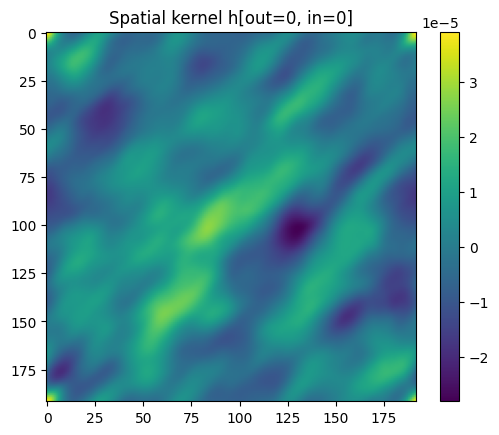

In [9]:
import matplotlib.pyplot as plt
k = kernels_0[0, 0].detach().cpu()
plt.imshow(k, aspect='equal')
plt.title("Spatial kernel h[out=0, in=0]")
plt.colorbar(); plt.show()

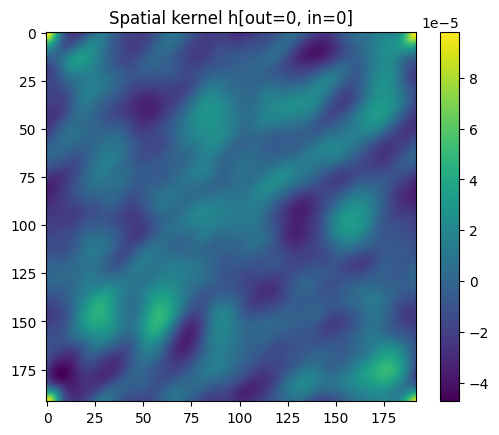

In [10]:
import matplotlib.pyplot as plt
k = kernels_0[1, 0].detach().cpu()
plt.imshow(k, aspect='equal')
plt.title("Spatial kernel h[out=0, in=0]")
plt.colorbar(); plt.show()

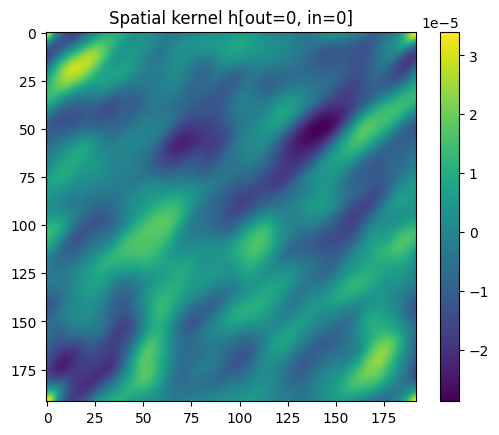

In [11]:
import matplotlib.pyplot as plt
k = kernels_0[70, 0].detach().cpu()
plt.imshow(k, aspect='equal')
plt.title("Spatial kernel h[out=0, in=0]")
plt.colorbar(); plt.show()

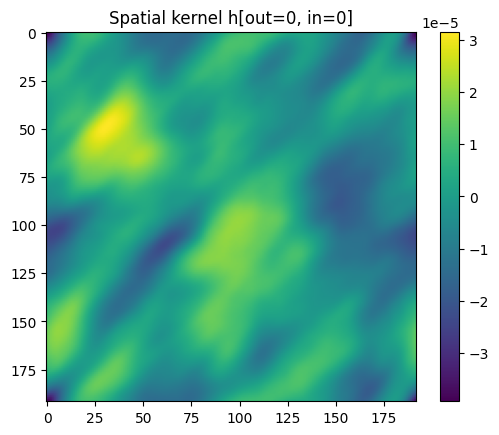

In [12]:
import matplotlib.pyplot as plt
k = kernels_0[70, 70].detach().cpu()
plt.imshow(k, aspect='equal')
plt.title("Spatial kernel h[out=0, in=0]")
plt.colorbar(); plt.show()

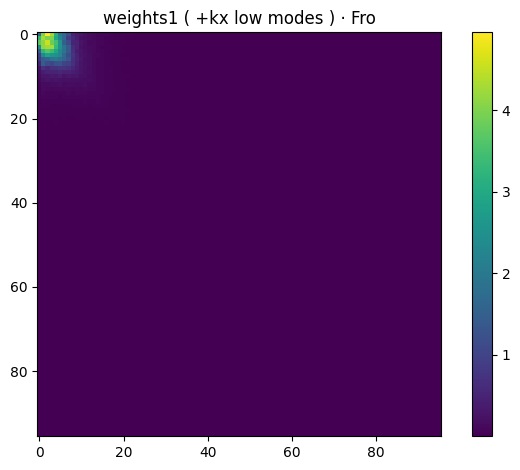

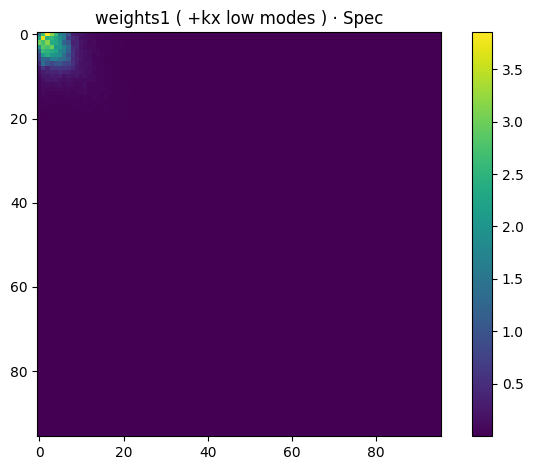

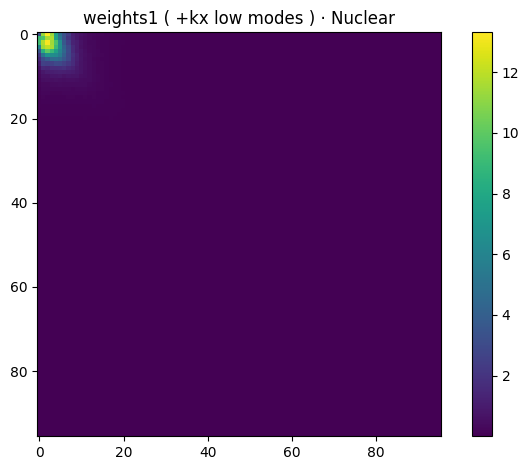

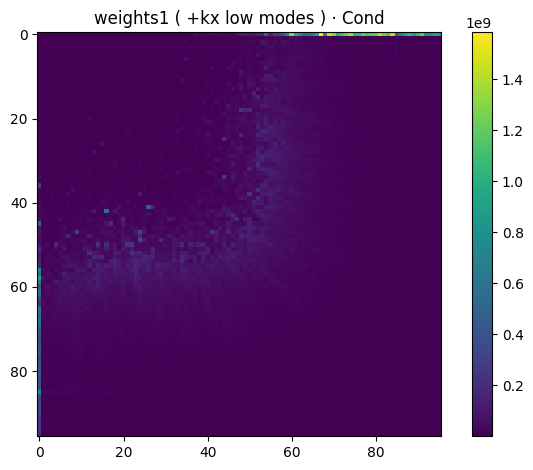

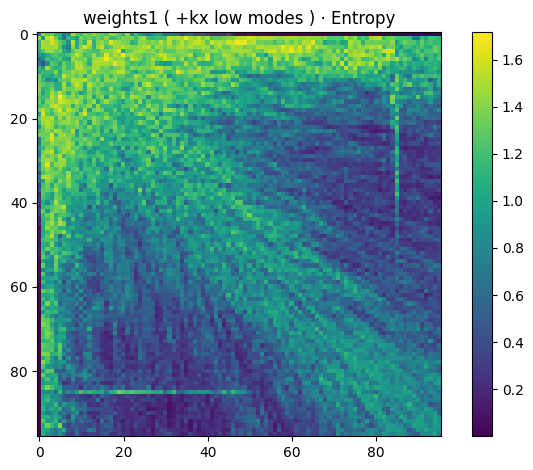

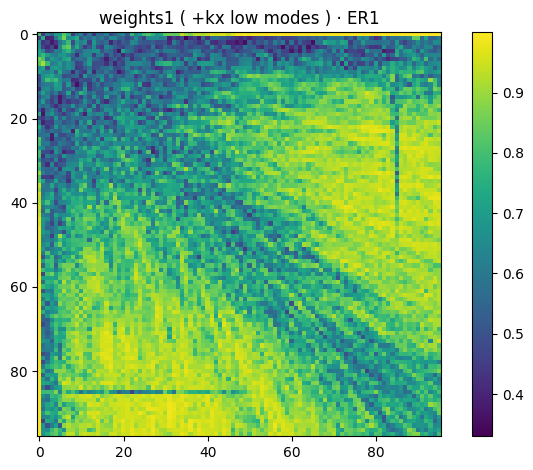

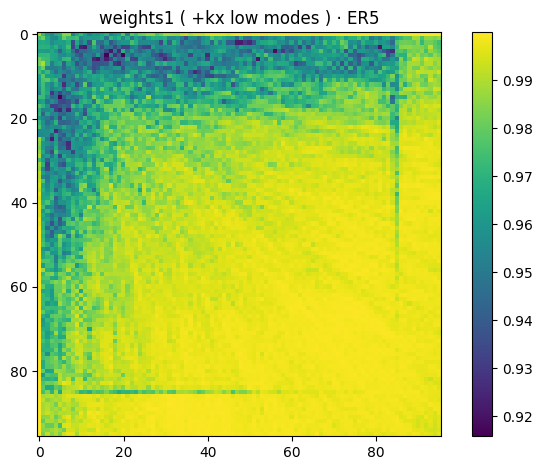

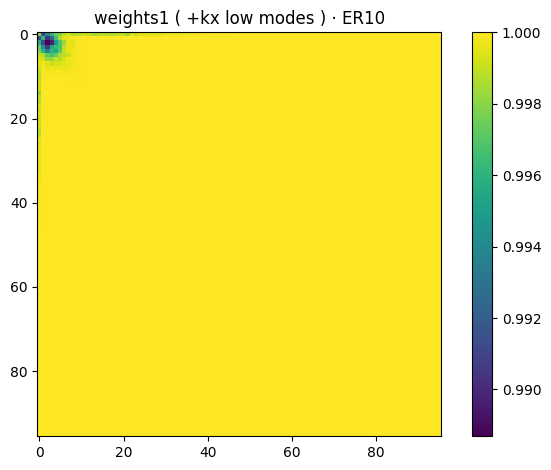

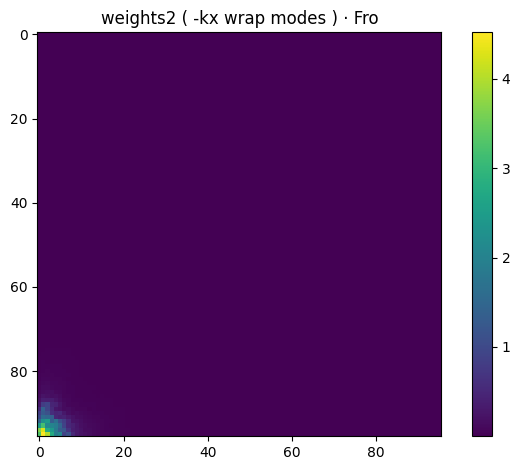

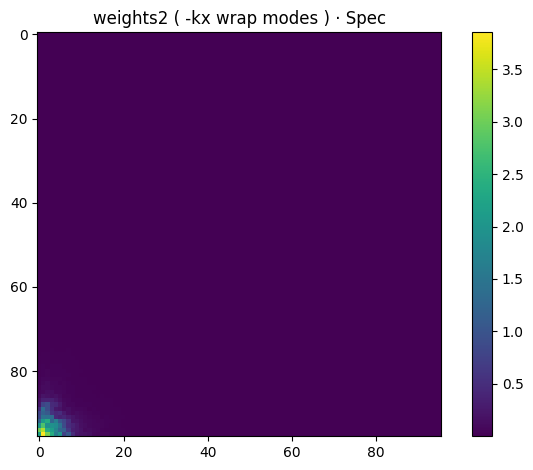

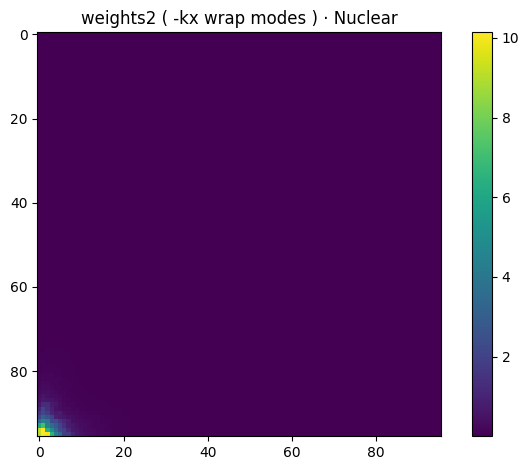

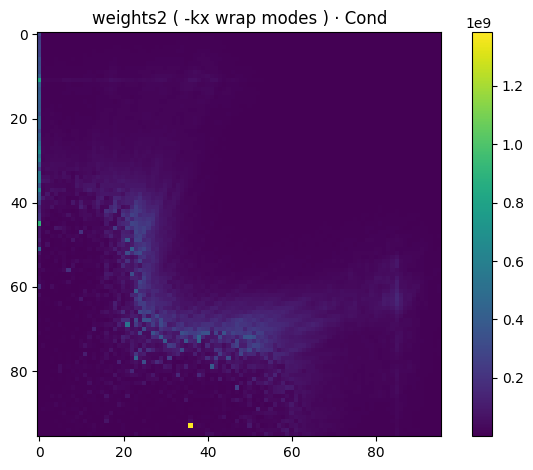

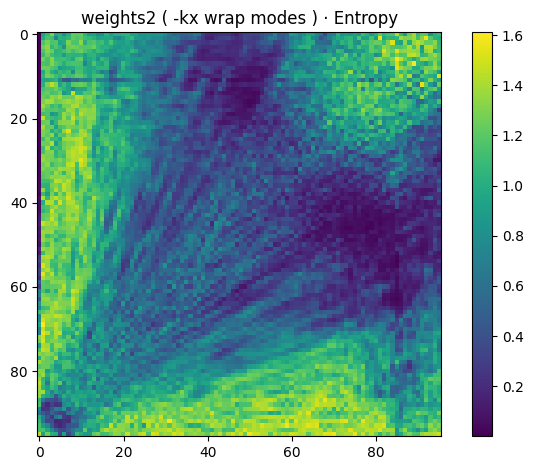

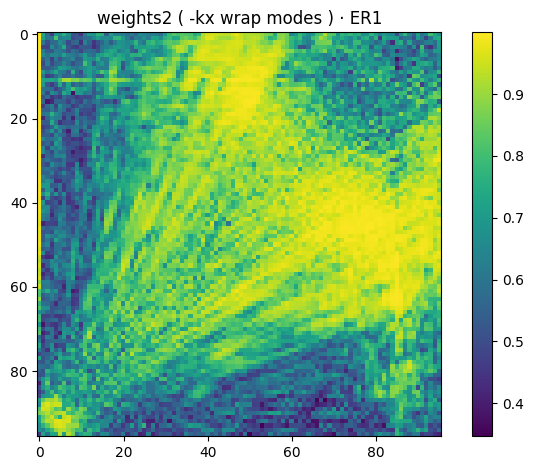

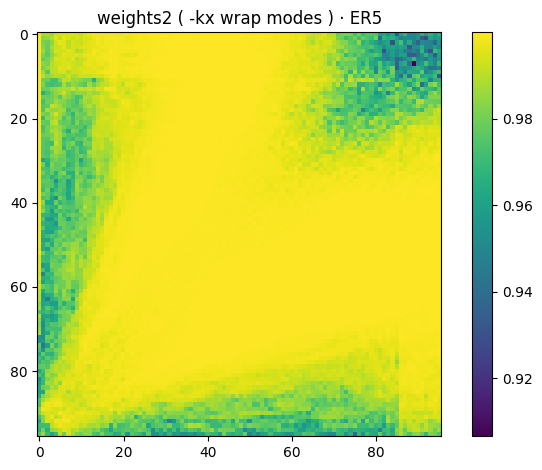

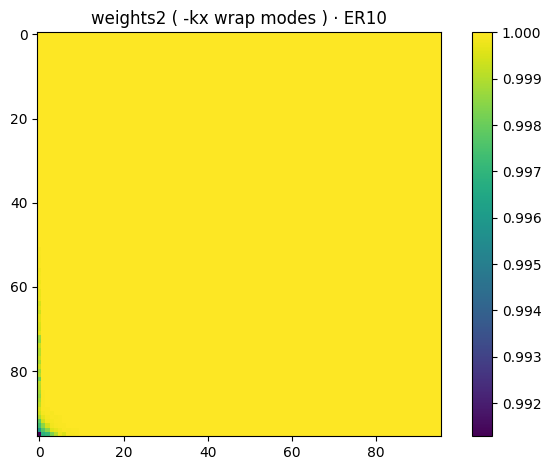

In [18]:
import torch
import math
import matplotlib.pyplot as plt

# ====== 工具：把一个 block 的 [cin, cout, m1, m2] 变成 batch 矩阵 [m1*m2, cout, cin] ======
def block_to_batch_mats(w):  # w: [cin, cout, m1, m2], complex
    cin, cout, m1, m2 = w.shape
    return w.permute(2, 3, 1, 0).reshape(m1*m2, cout, cin).contiguous(), (m1, m2)

# ====== 计算所有指标（对单 block，返回字典，含每个指标的[m1,m2]二维图） ======
@torch.no_grad()
def summarize_block_metrics(w, top_ks=(1,5,10)):
    # w: [cin, cout, m1, m2], complex
    B, (m1, m2) = block_to_batch_mats(w)              # [Nfreq, cout, cin]
    # 奇异值（只要奇异值更快，也可用 torch.linalg.svdvals）
    S = torch.linalg.svdvals(B)                       # [Nfreq, r], r=min(cout,cin)
    r = S.shape[-1]
    # 标量指标
    S2 = S**2                                         # [Nfreq, r]
    fro2 = S2.sum(-1)                                 # ||W||_F^2
    fro = fro2.sqrt()                                 # ||W||_F
    spec = S[..., 0]                                  # ||W||_2
    nuc = S.sum(-1)                                   # 核范数
    cond = spec / S[..., -1].clamp_min(1e-12)         # 条件数，避免除零

    # ER_k
    tot = S2.sum(-1, keepdim=True).clamp_min(1e-30)
    ers = {f"ER{k}": (S2[..., :min(k, r)].sum(-1) / tot.squeeze(-1)) for k in top_ks}

    # 奇异值分布熵（能量权重）
    p = (S2 / tot)                                    # [Nfreq, r]
    entropy = -(p * (p.clamp_min(1e-30).log())).sum(-1)

    def R(x): return x.reshape(m1, m2).detach().cpu()
    out = {
        "Fro": R(fro),
        "Spec": R(spec),
        "Nuclear": R(nuc),
        "Cond": R(cond),
        "Entropy": R(entropy),
    }
    for k, v in ers.items():
        out[k] = R(v)
    return out

# ====== 绘图（每个指标单独开一张图） ======
def plot_metric_heatmaps(metrics_dict, title_prefix="weights1"):
    for name, img in metrics_dict.items():
        plt.figure()
        plt.imshow(img, aspect='equal')  # 每张图单独一幅（避免子图挤压）
        plt.title(f"{title_prefix} · {name}")
        plt.colorbar()
        plt.tight_layout()
        plt.show()

# ====== 对某一层 SpectralConv2d 分别画 weights1 和 weights2 的所有指标 ======
def plot_all_metrics_for_spectral_layer(sconv: SpectralConv2d, top_ks=(1,5,10)):
    m_w1 = summarize_block_metrics(sconv.weights1, top_ks=top_ks)
    m_w2 = summarize_block_metrics(sconv.weights2, top_ks=top_ks)
    plot_metric_heatmaps(m_w1, title_prefix="weights1 ( +kx low modes )")
    plot_metric_heatmaps(m_w2, title_prefix="weights2 ( -kx wrap modes )")

# ====== 例子：对 FNO2d 的第 i 层 ======
core = model.model if hasattr(model, "model") else model  # 如果包在 RecurrentPredictor 里就解包
i = 0  # 选一层
plot_all_metrics_for_spectral_layer(core.conv_layers[i], top_ks=(1,5,10))


In [ ]:
import torch
import matplotlib.pyplot as plt
from collections import OrderedDict

# ===== 1) 频域权重 → 空间域脉冲响应核  [in, out, H, W] =====
@torch.no_grad()
def spectral_weights_to_spatial_kernels(sconv, size_x: int, size_y: int, norm=None):
    """
    把 SpectralConv2d 的两块低频权重 weights1/weights2 填回 rfft2 的单边谱布局，
    然后 irfft2 得到空间域核。输出: [in, out, size_x, size_y] (real)
    """
    m1, m2 = sconv.modes1, sconv.modes2
    cin, cout = sconv.in_channels, sconv.out_channels
    device = sconv.weights1.device

    # rfft2/irfft2 的单边谱: 最后一维长度为 Ny//2 + 1
    spec = torch.zeros(cin, cout, size_x, size_y//2 + 1, dtype=torch.cfloat, device=device)
    spec[:, :, :m1, :m2]  = sconv.weights1                 # 正 kx 低频带
    spec[:, :, -m1:, :m2] = sconv.weights2                 # 负 kx 低频带（wrap 到顶端）
    # 逆变换得到空间核（实值），norm 可选: None/"ortho"/"forward"
    # 参考: irfft2 输入解释为 rfft2 的单边厄米谱，输出必为实数
    kernels_space = torch.fft.irfft2(spec, s=(size_x, size_y), norm=norm)
    return kernels_space  # [in, out, H, W], float

# ===== 2) 把每个像素位移 (x,y) 的通道映射矩阵堆成 batch: [H*W, out, in] =====
def space_block_to_batch_mats(kernels_space):
    # kernels_space: [in, out, H, W]
    k = kernels_space.permute(2, 3, 1, 0)   # -> [H, W, out, in]
    H, W = k.shape[:2]
    B = k.reshape(H*W, k.shape[2], k.shape[3]).contiguous()  # [Npix, out, in]
    return B, (H, W)

# ===== 3) 空间域逐像素矩阵的指标（分块 SVD 防 OOM） =====
@torch.no_grad()
def summarize_space_metrics(kernels_space, top_ks=(1,5,10), chunk=4096):
    """
    对每个像素位置的 [out, in] 实矩阵做奇异值分析与范数指标。
    返回: dict[name] -> [H,W] 图
    """
    B, (H, W) = space_block_to_batch_mats(kernels_space)  # [N, out, in]
    N, outc, inc = B.shape
    r = min(outc, inc)

    # 预分配
    fro   = torch.empty(N, device=B.device)
    spec  = torch.empty(N, device=B.device)
    nuc   = torch.empty(N, device=B.device)
    cond  = torch.empty(N, device=B.device)
    entropy = torch.empty(N, device=B.device)
    ER = {k: torch.empty(N, device=B.device) for k in top_ks}

    # 逐块计算，避免一次性对 N 个 80x80 做 SVD 爆显存
    for start in range(0, N, chunk):
        end = min(start + chunk, N)
        Bi = B[start:end]                            # [M, out, in]
        # 奇异值（降序），svdvals 支持批量
        Si = torch.linalg.svdvals(Bi)                # [M, r]
        S2 = Si**2
        tot = S2.sum(-1, keepdim=True).clamp_min(1e-30)

        # 指标
        fro[start:end]  = S2.sum(-1).sqrt()          # Frobenius
        spec[start:end] = Si[..., 0]                 # 谱范数
        nuc[start:end]  = Si.sum(-1)                 # 核范数
        cond[start:end] = Si[..., 0] / Si[..., -1].clamp_min(1e-12)  # 条件数

        p = S2 / tot
        entropy[start:end] = -(p * (p.clamp_min(1e-30).log())).sum(-1)  # 能量熵

        for k in top_ks:
            kk = min(k, r)
            ER[k][start:end] = (S2[..., :kk].sum(-1) / tot.squeeze(-1))

    # reshape 回 [H,W] 并搬到 CPU
    def R(x): return x.reshape(H, W).detach().cpu()
    out = {
        "Fro": R(fro),
        "Spec": R(spec),
        "Nuclear": R(nuc),
        "Cond": R(cond),
        "Entropy": R(entropy),
    }
    for k, v in ER.items():
        out[f"ER{k}"] = R(v)
    return out

# ===== 4) 画图（每个指标单开一张） =====
def plot_metric_heatmaps(metrics_dict, title_prefix="space kernels"):
    for name, img in metrics_dict.items():
        plt.figure()
        plt.imshow(img, aspect='equal')
        plt.title(f"{title_prefix} · {name}")
        plt.colorbar()
        plt.tight_layout()
        plt.show()

# ===== 5) 一键：对某个 SpectralConv2d 层做“频→空”，再逐像素指标可视化 =====
def plot_space_metrics_for_layer(sconv, H=256, W=256, norm=None, top_ks=(1,5,10), chunk=4096):
    kernels_space = spectral_weights_to_spatial_kernels(sconv, H, W, norm=norm)  # [in,out,H,W]
    metrics = summarize_space_metrics(kernels_space, top_ks=top_ks, chunk=chunk)
    plot_metric_heatmaps(metrics, title_prefix=f"Spatial kernels (H={H}, W={W})")

# ==== 用法（例如第 0 层；若你的训练分辨率是 256×256，就 H=W=256）====
core = model.model if hasattr(model, "model") else model
i = 0
plot_space_metrics_for_layer(core.conv_layers[i], H=96*2, W=96*2, norm=None, top_ks=(1,5,10), chunk=2048)


In [ ]:
state.keys()

In [ ]:
# W = state['conv1.weight']                  # tensor
# W_np = W.detach().cpu().numpy() 
import matplotlib.pyplot as plt

W = state['fc.weight'].detach().cpu()      # [out, in]
plt.imshow(W, aspect='auto')
plt.title('fc.weight')
plt.colorbar(); plt.show()